In [1]:
import sys
sys.path.append("../src")          # so we can import the module

import sqlite3
from pathlib import Path
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from nlp_module import analyze_notes_dataframe

DB = Path("../data/processed/oral_oncology.db")
conn = sqlite3.connect(DB)

notes = pd.read_sql_query("SELECT * FROM clinical_notes", conn)
patients = pd.read_sql_query("SELECT patient_id, oral_cancer_positive FROM patients", conn)
print(f"Notes: {len(notes):,}")

Notes: 17,465


In [2]:
%%time
notes_enriched = analyze_notes_dataframe(notes, text_col="note_text")
notes_enriched.head()

CPU times: user 1.29 s, sys: 27.3 ms, total: 1.32 s
Wall time: 1.33 s


,note_id,patient_id,visit_id,note_date,note_text,extracted_terms,n_suspicious_terms,urgency_score,suspicious_flag,note_risk_category,benign_terms
0,N000001,P00001,V000001,2025-04-24,Adult prophy completed. Mild gingival inflamma...,[],0,0,0,None,[]
1,N000002,P00001,V000002,2025-11-03,Pt here for cleaning. No symptoms reported. To...,[],0,0,0,None,[]
2,N000003,P00001,V000003,2024-08-31,Routine 6mo recall. Pt denies any concerns. Or...,[],0,0,0,None,[]
3,N000004,P00001,V000004,2026-03-05,Pt here for cleaning. No symptoms reported. To...,[],0,0,0,None,[]
4,N000005,P00001,V000005,2024-04-08,Recall visit. Patient reports no oral pain or ...,[],0,0,0,None,[]


In [3]:
print(notes_enriched["note_risk_category"].value_counts())
print()
print(notes_enriched["urgency_score"].describe())

note_risk_category
None      16259
High        539
Medium      378
Low         289
Name: count, dtype: int64

count    17465.000000
mean         0.723504
std          3.039911
min          0.000000
25%          0.000000
50%          0.000000
75%          0.000000
max         21.000000
Name: urgency_score, dtype: float64


In [4]:
patient_nlp = notes_enriched.groupby("patient_id").agg(
    max_urgency_score=("urgency_score", "max"),
    total_urgency_score=("urgency_score", "sum"),
    any_suspicious=("suspicious_flag", "max"),
    n_high_risk_notes=("note_risk_category", lambda s: (s == "High").sum()),
).reset_index()

merged = patient_nlp.merge(patients, on="patient_id")

print("Cancer rate by max-urgency category:")
merged["urgency_bucket"] = pd.cut(merged["max_urgency_score"],
                                   bins=[-1, 0, 4, 9, 100],
                                   labels=["None", "Low", "Medium", "High"])
print(merged.groupby("urgency_bucket", observed=False)["oral_cancer_positive"].agg(["count", "mean"]).round(3))

Cancer rate by max-urgency category:
                count   mean
urgency_bucket              
None             4036  0.058
Low               193  0.181
Medium            281  0.132
High              490  0.143


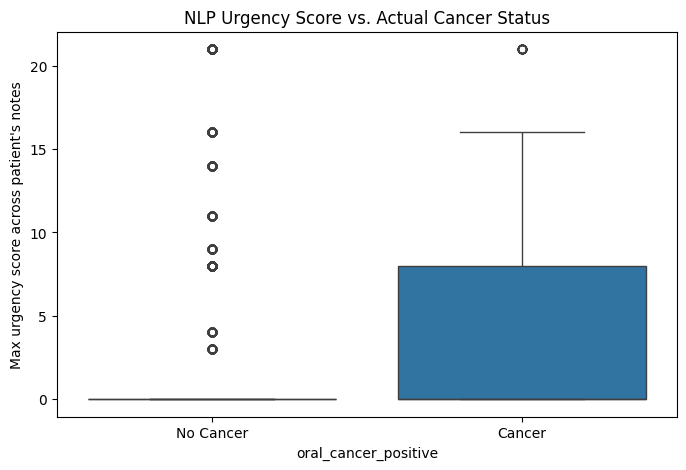

In [5]:
plt.figure(figsize=(8, 5))
sns.boxplot(data=merged, x="oral_cancer_positive", y="max_urgency_score")
plt.xticks([0, 1], ["No Cancer", "Cancer"])
plt.title("NLP Urgency Score vs. Actual Cancer Status")
plt.ylabel("Max urgency score across patient's notes")
plt.show()

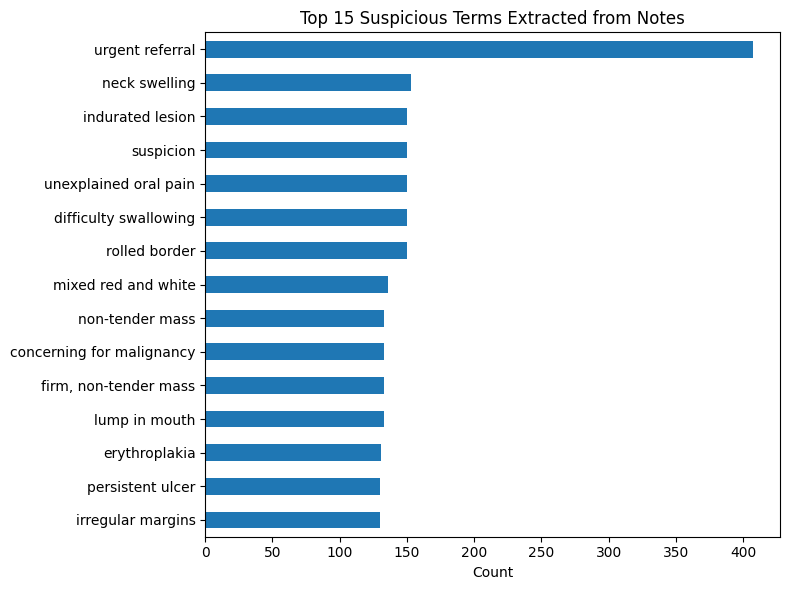

In [6]:
from collections import Counter

all_terms = []
for terms in notes_enriched["extracted_terms"]:
    all_terms.extend(terms)

term_counts = pd.Series(Counter(all_terms)).sort_values(ascending=False).head(15)
term_counts.plot(kind="barh", figsize=(8, 6))
plt.gca().invert_yaxis()
plt.title("Top 15 Suspicious Terms Extracted from Notes")
plt.xlabel("Count")
plt.tight_layout()
plt.show()

In [7]:
out = Path("../data/processed/clinical_notes_enriched.csv")
# Drop list columns before CSV (CSVs don't handle lists well)
to_save = notes_enriched.copy()
to_save["extracted_terms"] = to_save["extracted_terms"].apply(lambda x: "|".join(x))
to_save["benign_terms"]    = to_save["benign_terms"].apply(lambda x: "|".join(x))
to_save.to_csv(out, index=False)
print(f"Saved: {out}")

Saved: ../data/processed/clinical_notes_enriched.csv
